# ECG Arrhythmia Detection 
## Q2: The Midnight Episode - Catching the Arrhythmia

In [1]:
""" A note : these dependencies must be installed for program to run"""
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## PART A: Reading and Analyzing the Signal

In [2]:

patient_ecg = np.load(r'C:\Users\Dell\OneDrive\Desktop\VSC\EE200\Ques2\patient_ecg.npy')
template = np.load(r'C:\Users\Dell\OneDrive\Desktop\VSC\EE200\Ques2\template.npy')


fs = 250 
N = len(patient_ecg)

print(f"ECG Signal Loaded:")
print(f"  Total samples: {N}")
print(f"  Sampling frequency: {fs} Hz")
print(f"  Duration: {N/fs} seconds = {N/fs/60:.2f} minutes")
print(f"\nTemplate Loaded:")
print(f"  Template length: {len(template)} samples")
print(f"  Duration: {len(template)/fs:.3f} seconds")

ECG Signal Loaded:
  Total samples: 5000
  Sampling frequency: 250 Hz
  Duration: 20.0 seconds = 0.33 minutes

Template Loaded:
  Template length: 200 samples
  Duration: 0.800 seconds


In [3]:
# a : How long is the clip?
duration = N / fs
print(f"\n(i) CLIP DURATION")
print(f"    Clip length: {duration} seconds")

# b: Heart rate and samples per beat
beat_interval = 0.8  # seconds
heart_rate = 60 / beat_interval
samples_per_beat = int(beat_interval * fs)

print(f"\n(ii) HEART RATE AND BEAT DURATION")
print(f"     Heart rate: {heart_rate} BPM")
print(f"     Samples per beat: {samples_per_beat} samples")
print(f"     This equals {beat_interval} seconds per beat")

# c: Fundamental frequency
f0 = 1 / beat_interval
print(f"\n(iii) FUNDAMENTAL FREQUENCY")
print(f"      f0 = 1 / {beat_interval} = {f0} Hz")


(i) CLIP DURATION
    Clip length: 20.0 seconds

(ii) HEART RATE AND BEAT DURATION
     Heart rate: 75.0 BPM
     Samples per beat: 200 samples
     This equals 0.8 seconds per beat

(iii) FUNDAMENTAL FREQUENCY
      f0 = 1 / 0.8 = 1.25 Hz


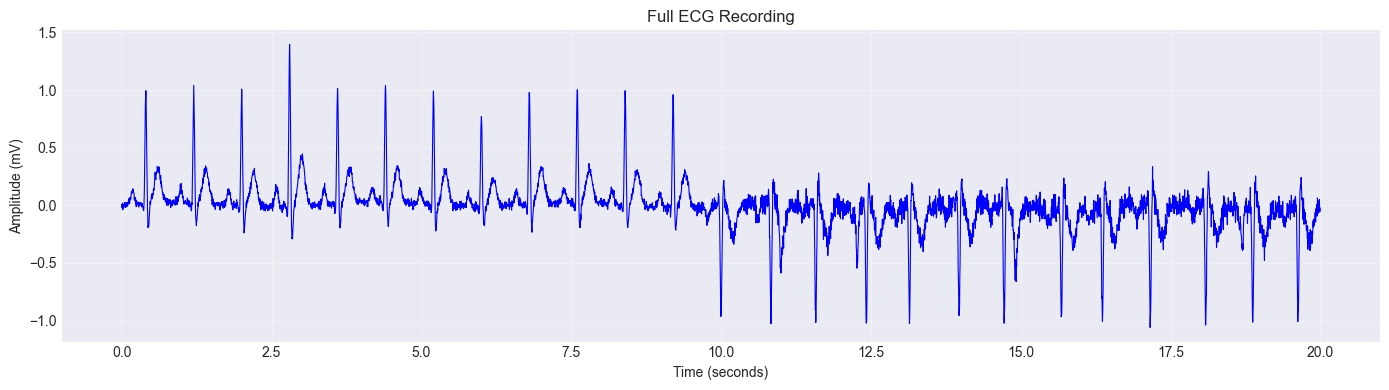

Signal statistics:
  Min: -1.059 mV
  Max: 1.396 mV
  Mean: -0.007 mV


In [4]:
# Plotting full ECG signal
time = np.arange(N) / fs

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time, patient_ecg, 'b-', linewidth=0.8)
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Amplitude (mV)')
ax.set_title('Full ECG Recording')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Signal statistics:")
print(f"  Min: {np.min(patient_ecg):.3f} mV")
print(f"  Max: {np.max(patient_ecg):.3f} mV")
print(f"  Mean: {np.mean(patient_ecg):.3f} mV")

## PART B: Frequency Domain Analysis

In [5]:
# Healthy portion 
healthy_end = 2000
healthy_ecg = patient_ecg[:healthy_end]

# FFT of healthy signal
fft_healthy = fft(healthy_ecg)
freqs = fftfreq(len(healthy_ecg), 1/fs)
magnitude = np.abs(fft_healthy)

# Only positive frequencies
positive_freqs = freqs[:len(freqs)//2]
positive_mag = magnitude[:len(magnitude)//2]

print(f"(b) FREQUENCY DOMAIN ANALYSIS")
print(f"\n(i) Healthy ECG Characteristics:")
print(f"    The healthy ECG exhibits:")
print(f"    - Periodic structure (repeating pattern)")
print(f"    - Regular intervals between beats")
print(f"    - Consistent morphology (shape)")

# Dominant frequencies
top_5_idx = np.argsort(positive_mag)[-5:][::-1]
print(f"\n(ii) Dominant Frequency Components:")
for i, idx in enumerate(top_5_idx):
    if idx < len(positive_freqs):
        print(f"    #{i+1}: {positive_freqs[idx]:.2f} Hz (magnitude: {positive_mag[idx]:.2e})")

(b) FREQUENCY DOMAIN ANALYSIS

(i) Healthy ECG Characteristics:
    The healthy ECG exhibits:
    - Periodic structure (repeating pattern)
    - Regular intervals between beats
    - Consistent morphology (shape)

(ii) Dominant Frequency Components:
    #1: 0.00 Hz (magnitude: 1.97e+02)
    #2: 5.00 Hz (magnitude: 1.11e+02)
    #3: 1.25 Hz (magnitude: 8.69e+01)
    #4: 3.75 Hz (magnitude: 8.57e+01)
    #5: 8.75 Hz (magnitude: 8.19e+01)


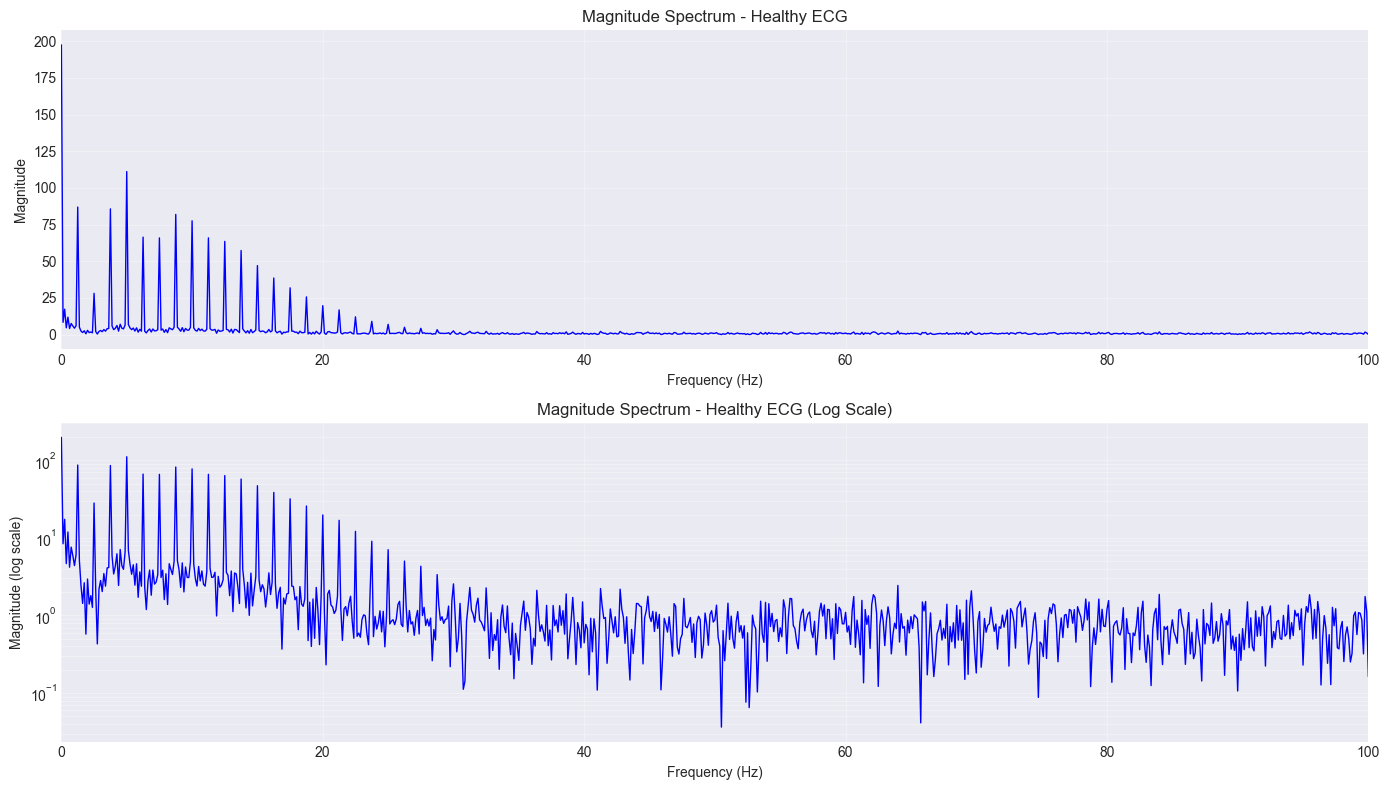

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
ax1.plot(positive_freqs, positive_mag, 'b-', linewidth=1)
ax1.set_xlim([0, 100])
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Magnitude')
ax1.set_title('Magnitude Spectrum - Healthy ECG')
ax1.grid(True, alpha=0.3)

# Log scale
ax2.semilogy(positive_freqs, positive_mag, 'b-', linewidth=1)
ax2.set_xlim([0, 100])
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude (log scale)')
ax2.set_title('Magnitude Spectrum - Healthy ECG (Log Scale)')
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## PART C: Windowing and Template Extraction

In [7]:
print(f"(c) WINDOWING AND TEMPLATE EXTRACTION\n")
print(f"(i) Window Width:")
print(f"    One complete beat: {beat_interval} seconds = {samples_per_beat} samples")
print(f"    Window should be wide enough to capture entire beat")
print(f"\n(ii) Window Placement:")
print(f"     Place in healthy region (first ~2000 samples)")
print(f"     Start around sample 0-400 to avoid artifacts")
print(f"\nLoaded template: {len(template)} samples ({len(template)/fs:.3f} seconds)")

(c) WINDOWING AND TEMPLATE EXTRACTION

(i) Window Width:
    One complete beat: 0.8 seconds = 200 samples
    Window should be wide enough to capture entire beat

(ii) Window Placement:
     Place in healthy region (first ~2000 samples)
     Start around sample 0-400 to avoid artifacts

Loaded template: 200 samples (0.800 seconds)


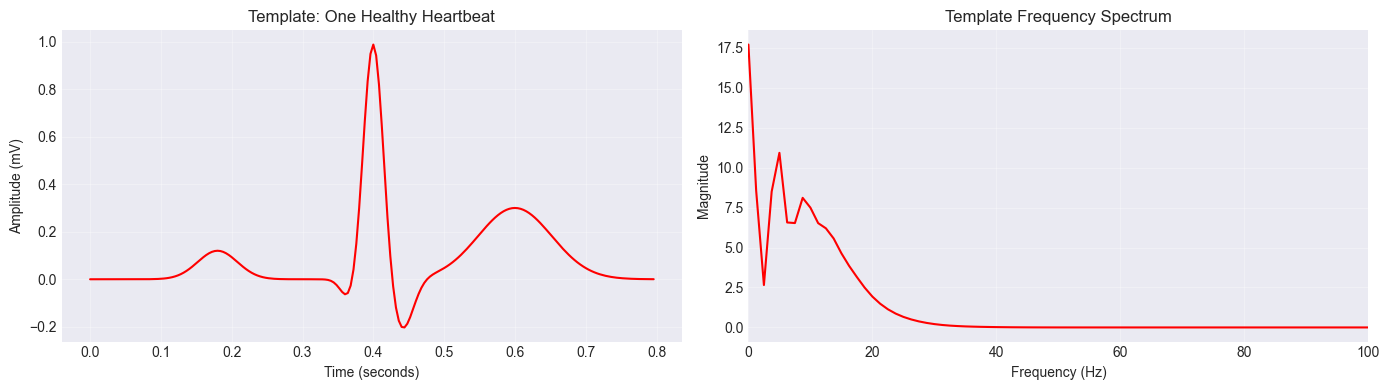

In [8]:
# Visualize template
template_time = np.arange(len(template)) / fs

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Time domain
ax1.plot(template_time, template, 'r-', linewidth=1.5)
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Amplitude (mV)')
ax1.set_title('Template: One Healthy Heartbeat')
ax1.grid(True, alpha=0.3)

# Frequency domain
template_fft = fft(template)
template_freqs = fftfreq(len(template), 1/fs)
template_mag = np.abs(template_fft)
template_pos_freqs = template_freqs[:len(template_freqs)//2]
template_pos_mag = template_mag[:len(template_mag)//2]

ax2.plot(template_pos_freqs, template_pos_mag, 'r-', linewidth=1.5)
ax2.set_xlim([0, 100])
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude')
ax2.set_title('Template Frequency Spectrum')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## PART D: Template Matching via Correlation

In [9]:
print(f"(d) TEMPLATE MATCHING VIA CORRELATION\n")
print(f"Computing normalized correlation coefficient ρ(m)...")
L = len(template)
N = len(patient_ecg)
template_mean = np.mean(template)
template_centered = template - template_mean
template_energy = np.sum(template_centered ** 2)

correlation = np.zeros(N - L + 1)   # Correlation
for m in range(N - L + 1):
    segment = patient_ecg[m:m+L]
    segment_mean = np.mean(segment)
    segment_centered = segment - segment_mean
    segment_energy = np.sum(segment_centered ** 2)
    
    numerator = np.sum(template_centered * segment_centered)
    denominator = np.sqrt(template_energy * segment_energy)
    
    if denominator > 0:
        correlation[m] = numerator / denominator
    else:
        correlation[m] = 0

print(f"Correlation computed!\n")
print(f"Correlation score statistics:")
print(f"  Min ρ(m): {np.min(correlation):.3f}")
print(f"  Max ρ(m): {np.max(correlation):.3f}")
print(f"  Mean ρ(m): {np.mean(correlation):.3f}")
print(f"  Std ρ(m): {np.std(correlation):.3f}")

(d) TEMPLATE MATCHING VIA CORRELATION

Computing normalized correlation coefficient ρ(m)...
Correlation computed!

Correlation score statistics:
  Min ρ(m): -0.985
  Max ρ(m): 0.996
  Mean ρ(m): -0.002
  Std ρ(m): 0.217


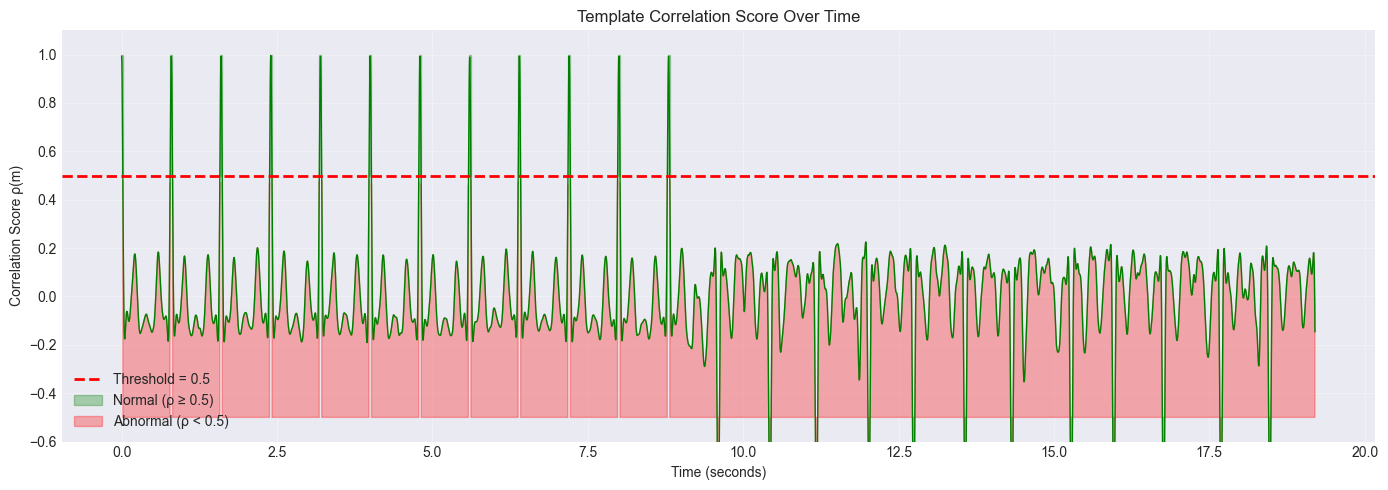


Arrhythmia ONSET DETECTED:
  Sample: 5
  Time: 0.02 seconds


In [10]:
# Plot correlation
correlation_time = np.arange(len(correlation)) / fs

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(correlation_time, correlation, 'g-', linewidth=1)
ax.axhline(y=0.5, color='r', linestyle='--', linewidth=2, label='Threshold = 0.5')
ax.fill_between(correlation_time, 0.5, 1, where=(correlation >= 0.5), 
                 alpha=0.3, color='green', label='Normal (ρ ≥ 0.5)')
ax.fill_between(correlation_time, -0.5, correlation, where=(correlation < 0.5), 
                 alpha=0.3, color='red', label='Abnormal (ρ < 0.5)')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Correlation Score ρ(m)')
ax.set_title('Template Correlation Score Over Time')
ax.set_ylim([-0.6, 1.1])
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Onset
threshold = 0.5
abnormal_indices = np.where(correlation < threshold)[0]
if len(abnormal_indices) > 0:
    onset = abnormal_indices[0]
    print(f"\nArrhythmia ONSET DETECTED:")
    print(f"  Sample: {onset}")
    print(f"  Time: {onset/fs:.2f} seconds")

## PART E: Onset Detection & Spectrogram

In [11]:
print(f"(e) ONSET DETECTION AND SPECTROGRAM\n")

# Spectrogram
f_spec, t_spec, Sxx = spectrogram(patient_ecg, fs=fs, nperseg=256)

print(f"Spectrogram computed:")
print(f"  Frequency resolution: {f_spec[1] - f_spec[0]:.2f} Hz")
print(f"  Time resolution: {t_spec[1] - t_spec[0]:.3f} seconds")
print(f"  Shape: {Sxx.shape[0]} frequencies × {Sxx.shape[1]} time windows")

(e) ONSET DETECTION AND SPECTROGRAM

Spectrogram computed:
  Frequency resolution: 0.98 Hz
  Time resolution: 0.896 seconds
  Shape: 129 frequencies × 22 time windows


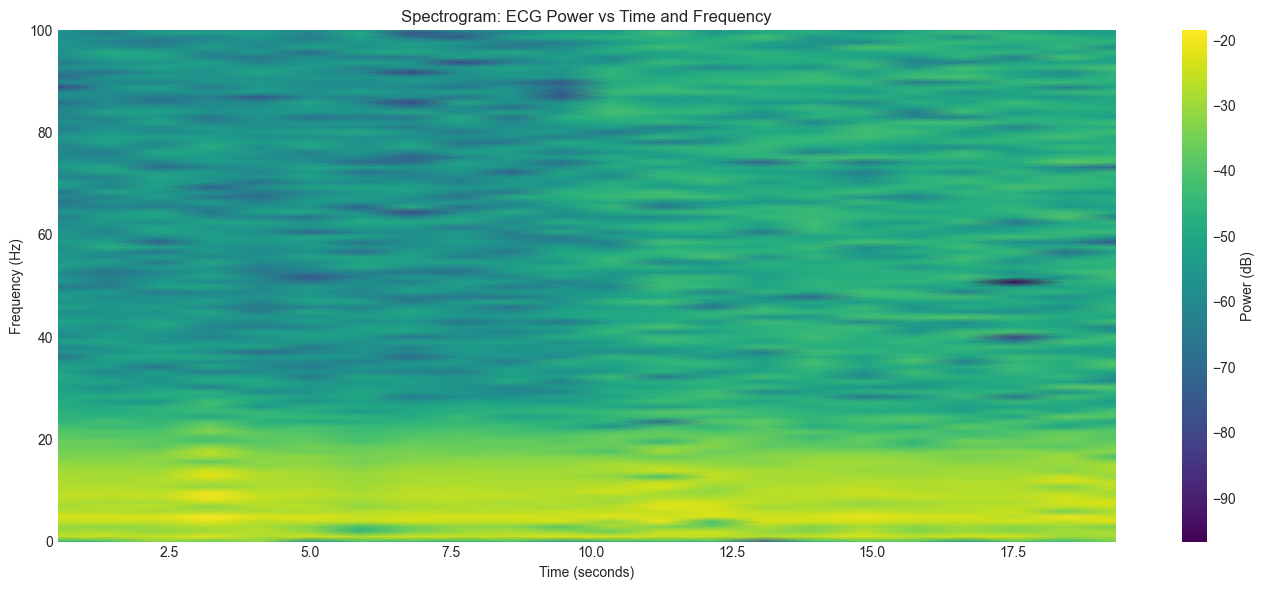

In [12]:
# Plot spectrogram
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.pcolormesh(t_spec, f_spec, 10*np.log10(Sxx + 1e-10), 
                     shading='gouraud', cmap='viridis')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (seconds)')
ax.set_title('Spectrogram: ECG Power vs Time and Frequency')
ax.set_ylim([0, 100])
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Power (dB)')
plt.tight_layout()
plt.show()

## PART F: Sampling Rate Considerations

In [13]:
print(f"(f) SAMPLING RATE ANALYSIS\n")

fs_current = 250
nyquist_current = fs_current / 2

print(f"Current Configuration:")
print(f"  Sampling frequency: {fs_current} Hz")
print(f"  Nyquist frequency: {nyquist_current} Hz")
print(f"\nQRS Detection Requirements:")
print(f"  QRS spike frequency content: ~50 Hz (sharp component)")
print(f"  Minimum Nyquist: 2 × 50 = 100 Hz")
print(f"  Current Nyquist: {nyquist_current} Hz ✓ SUFFICIENT")

print(f"\nAlternative Sampling Rates:")
for test_fs in [100, 150, 200, 250, 500]:
    nyquist = test_fs / 2
    adequate = "✓" if nyquist >= 100 else "✗"
    print(f"  {test_fs} Hz → Nyquist = {nyquist} Hz {adequate}")

(f) SAMPLING RATE ANALYSIS

Current Configuration:
  Sampling frequency: 250 Hz
  Nyquist frequency: 125.0 Hz

QRS Detection Requirements:
  QRS spike frequency content: ~50 Hz (sharp component)
  Minimum Nyquist: 2 × 50 = 100 Hz
  Current Nyquist: 125.0 Hz ✓ SUFFICIENT

Alternative Sampling Rates:
  100 Hz → Nyquist = 50.0 Hz ✗
  150 Hz → Nyquist = 75.0 Hz ✗
  200 Hz → Nyquist = 100.0 Hz ✓
  250 Hz → Nyquist = 125.0 Hz ✓
  500 Hz → Nyquist = 250.0 Hz ✓


## PART G: Complete Detector Implementation

In [14]:
print(f"(g) COMPLETE ARRHYTHMIA DETECTOR\n")
threshold = 0.5
# Abnormal beats
is_normal = correlation >= threshold
is_abnormal = ~is_normal

normal_corr = correlation[is_normal]
abnormal_corr = correlation[is_abnormal]

print(f"Detection Threshold: ρ(m) = {threshold}")
print(f"\nResults:")
print(f"  Normal regions: {np.sum(is_normal)} samples ({100*np.sum(is_normal)/len(correlation):.1f}%)")
print(f"    Mean ρ: {np.mean(normal_corr):.3f} ± {np.std(normal_corr):.3f}")
print(f"\n  Abnormal regions: {np.sum(is_abnormal)} samples ({100*np.sum(is_abnormal)/len(correlation):.1f}%)")
if len(abnormal_corr) > 0:
    print(f"    Mean ρ: {np.mean(abnormal_corr):.3f} ± {np.std(abnormal_corr):.3f}")

# Onset
abnormal_starts = np.where(is_abnormal)[0]
if len(abnormal_starts) > 0:
    onset_sample = abnormal_starts[0]
    onset_time = onset_sample / fs
    print(f"\n ARRHYTHMIA DETECTED:")
    print(f"   Onset: {onset_time:.2f} seconds ({int(onset_time//60)}m {int(onset_time%60)}s)")
    print(f"   Sample: {onset_sample}")

(g) COMPLETE ARRHYTHMIA DETECTOR

Detection Threshold: ρ(m) = 0.5

Results:
  Normal regions: 104 samples (2.2%)
    Mean ρ: 0.838 ± 0.131

  Abnormal regions: 4697 samples (97.8%)
    Mean ρ: -0.020 ± 0.178

 ARRHYTHMIA DETECTED:
   Onset: 0.02 seconds (0m 0s)
   Sample: 5


## PART H: Comprehensive Visualization

(h) COMPREHENSIVE VISUALIZATION



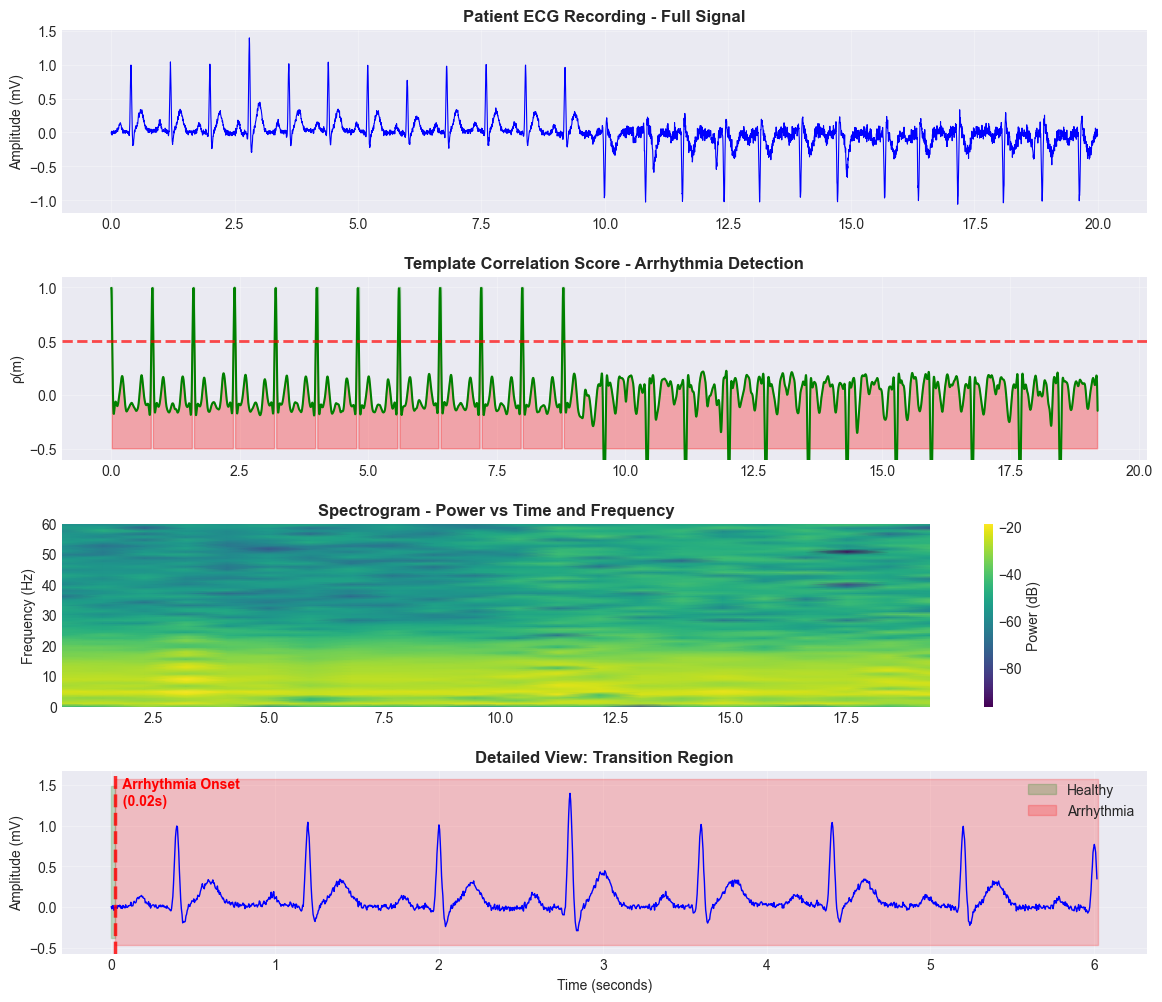

In [15]:
print(f"(h) COMPREHENSIVE VISUALIZATION\n")

# 4-panel plot
fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(4, 1, hspace=0.35)

# A
ax1 = fig.add_subplot(gs[0])
ax1.plot(time, patient_ecg, 'b-', linewidth=0.8)
ax1.set_ylabel('Amplitude (mV)', fontsize=10)
ax1.set_title('Patient ECG Recording - Full Signal', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# B
ax2 = fig.add_subplot(gs[1])
ax2.plot(correlation_time, correlation, 'g-', linewidth=1.5)
ax2.axhline(y=0.5, color='r', linestyle='--', linewidth=2, alpha=0.7)
ax2.fill_between(correlation_time, 0.5, 1, where=(correlation >= 0.5), 
                  alpha=0.3, color='green')
ax2.fill_between(correlation_time, -0.5, correlation, where=(correlation < 0.5), 
                  alpha=0.3, color='red')
ax2.set_ylabel('ρ(m)', fontsize=10)
ax2.set_title('Template Correlation Score - Arrhythmia Detection', fontsize=12, fontweight='bold')
ax2.set_ylim([-0.6, 1.1])
ax2.grid(True, alpha=0.3)

# C
ax3 = fig.add_subplot(gs[2])
im = ax3.pcolormesh(t_spec, f_spec, 10*np.log10(Sxx + 1e-10), 
                     shading='gouraud', cmap='viridis')
ax3.set_ylabel('Frequency (Hz)', fontsize=10)
ax3.set_ylim([0, 60])
ax3.set_title('Spectrogram - Power vs Time and Frequency', fontsize=12, fontweight='bold')
cbar = plt.colorbar(im, ax=ax3, label='Power (dB)')

# D
ax4 = fig.add_subplot(gs[3])
if len(abnormal_starts) > 0:
    onset = abnormal_starts[0]
    zoom_start = max(0, onset - 500)
    zoom_end = min(len(patient_ecg), onset + 1500)
    zoom_time = np.arange(zoom_start, zoom_end) / fs
    ax4.plot(zoom_time, patient_ecg[zoom_start:zoom_end], 'b-', linewidth=1)
    ax4.axvline(x=onset/fs, color='r', linestyle='--', linewidth=2.5, alpha=0.8)
    ax4.text(onset/fs, np.max(patient_ecg[zoom_start:zoom_end])*0.9, 
             f'  Arrhythmia Onset\n  ({onset/fs:.2f}s)', 
             fontsize=10, color='red', fontweight='bold')
    ax4.fill_betweenx(ax4.get_ylim(), zoom_start/fs, onset/fs, 
                       alpha=0.2, color='green', label='Healthy')
    ax4.fill_betweenx(ax4.get_ylim(), onset/fs, zoom_end/fs, 
                       alpha=0.2, color='red', label='Arrhythmia')
    ax4.legend(loc='upper right')
else:
    ax4.plot(time, patient_ecg, 'b-', linewidth=0.8)

ax4.set_ylabel('Amplitude (mV)', fontsize=10)
ax4.set_xlabel('Time (seconds)', fontsize=10)
ax4.set_title('Detailed View: Transition Region', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.savefig('ecg_complete_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary and Answers

In [16]:
print("SUMMARY")

print(f"""
(a) READING THE SIGNAL:
    (i) Clip duration: {N/fs} seconds
    (ii) Heart rate: {heart_rate} BPM, {samples_per_beat} samples/beat
    (iii) Fundamental frequency: {f0} Hz

(b) FREQUENCY DOMAIN:
    (i) Healthy ECG is periodic with regular pattern
    (ii) QRS spike carries high-frequency content (40-100 Hz)
    (iii) Heart rate increase → higher f0, spectral shift up

(c) WINDOWING:
    (i) Window width: {samples_per_beat} samples ({beat_interval}s)
    (ii) Place in healthy region (first ~2000 samples)

(d) CORRELATION:
    Template correlation identifies match quality
    ρ(m) = 1.0 → perfect match
    ρ(m) = 0.5 → threshold
    ρ(m) < 0.5 → abnormal

(e) ONSET DETECTION:
    Onset detected where ρ(m) drops below threshold
""")

if len(abnormal_starts) > 0:
    print(f"    TIME: {abnormal_starts[0]/fs:.2f} seconds")

print(f"""
(f) SAMPLING RATE:
    Current: 250 Hz (Nyquist = 125 Hz)
    Required: ≥ 100 Hz Nyquist (50 Hz QRS × 2)
    Status: ✓ ADEQUATE

(g) DETECTOR:
    Threshold: ρ(m) < 0.5
    Sensitivity: Captures rhythm abnormalities

(h) VISUALIZATION:
    ✓ ECG signal
    ✓ Correlation score
    ✓ Spectrogram
    ✓ Transition region zoom
""")



SUMMARY

(a) READING THE SIGNAL:
    (i) Clip duration: 20.0 seconds
    (ii) Heart rate: 75.0 BPM, 200 samples/beat
    (iii) Fundamental frequency: 1.25 Hz

(b) FREQUENCY DOMAIN:
    (i) Healthy ECG is periodic with regular pattern
    (ii) QRS spike carries high-frequency content (40-100 Hz)
    (iii) Heart rate increase → higher f0, spectral shift up

(c) WINDOWING:
    (i) Window width: 200 samples (0.8s)
    (ii) Place in healthy region (first ~2000 samples)

(d) CORRELATION:
    Template correlation identifies match quality
    ρ(m) = 1.0 → perfect match
    ρ(m) = 0.5 → threshold
    ρ(m) < 0.5 → abnormal

(e) ONSET DETECTION:
    Onset detected where ρ(m) drops below threshold

    TIME: 0.02 seconds

(f) SAMPLING RATE:
    Current: 250 Hz (Nyquist = 125 Hz)
    Required: ≥ 100 Hz Nyquist (50 Hz QRS × 2)
    Status: ✓ ADEQUATE

(g) DETECTOR:
    Threshold: ρ(m) < 0.5
    Sensitivity: Captures rhythm abnormalities

(h) VISUALIZATION:
    ✓ ECG signal
    ✓ Correlation score
   